<a href="https://colab.research.google.com/github/wejdanaljohani-hue/Arabic-Customer-Reviews-Sentiment-Analysis/blob/main/DS_483__phase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS- 483**
# **NLP Project**
# **Arabic Customer Reviews Sentiment Analysis**

### This project analyzes Arabic customer reviews to understand users’ opinions using **Natural Language Processing (NLP).**
### The goal is to classify reviews into positive, negative, or neutral sentiments and explore common patterns in the feedback.

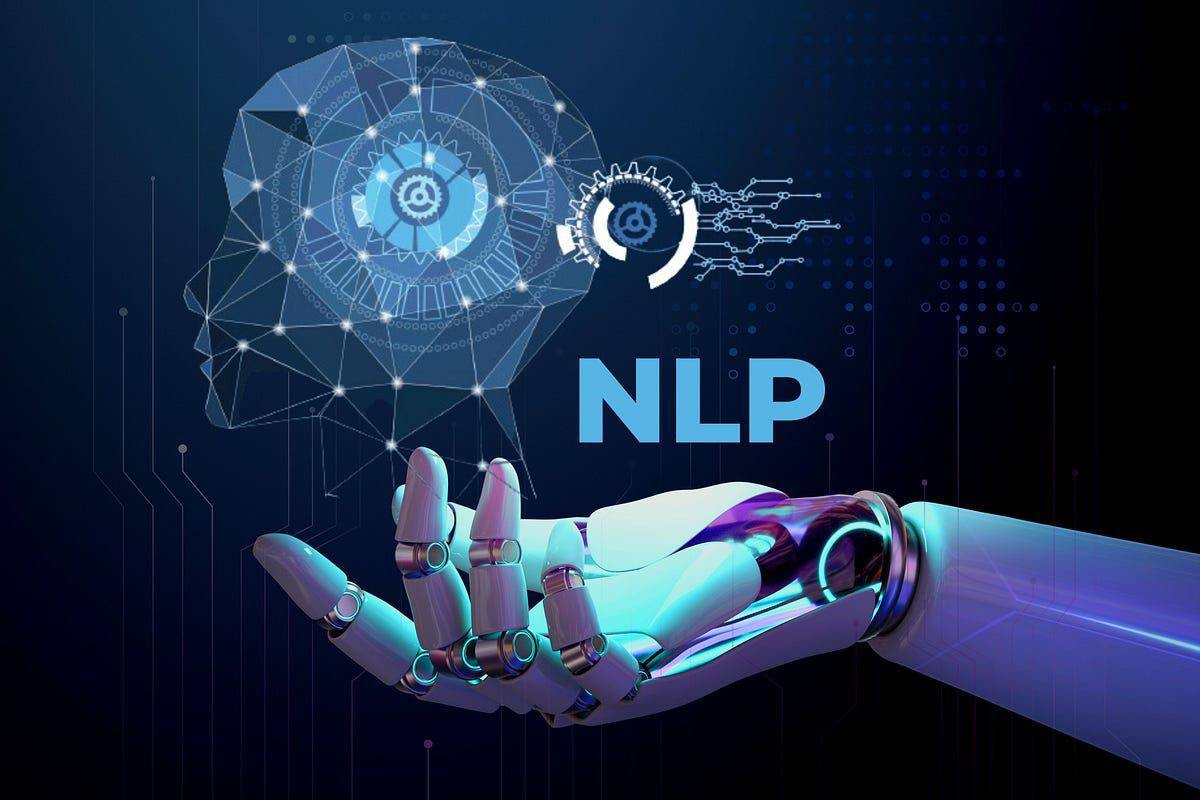

**Supervised by: Dr.Nada Almarwani**

Import Libraries:

In [ ]:
from IPython.display import clear_output
!pip install emoji
!pip install nltk
!pip install qalsadi
clear_output()

In [ ]:
import kagglehub
import pandas as pd
import re
from collections import Counter
import emoji
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
import qalsadi.lemmatizer as lem

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Load Dataset:

In [ ]:
# Download latest version of the data
# The file CompanyReviews.csv is already available in the Colab environment.
# The 'path' variable should now directly point to the file.
path = '/content'

print("Path to dataset files:", path)

Path to dataset files: /content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CompanyReviews.csv')
# display first rows
df.head()

,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


## Data Exploration:

In [ ]:
# to understand featurs and their types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          40046 non-null  int64 
 1   review_description  40045 non-null  object
 2   rating              40046 non-null  int64 
 3   company             40046 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.2+ MB


In [ ]:
# check if there is missing values
df.isna().sum()

,0
Unnamed: 0,0
review_description,1
rating,0
company,0


## Initial Data Cleaning:

In [ ]:
# since we have only one missing recored ,it's better to drop it
df.dropna(inplace=True)

In [ ]:
# drop the Unnamed feature
df = df.drop(df.columns[0], axis = 1)

In [ ]:
# replace the rating values for better understanding of the Customers overall sentiments
df['rating'] = df['rating'].replace({1: 'positive', -1 : 'negative', 0 : 'netural'})
df.head()

,review_description,rating,company
0,رائع,positive,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,positive,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,negative,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,negative,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,negative,talbat


In [ ]:
# Verify the dataset after Cleaning to ensure preprocessing worked correctly
print(f"Rows: {len(df)}")
print(f"nulls: {df["review_description"].isna().sum()}")
df.sample(10)

Rows: 40045
nulls: 0


,review_description,rating,company
2399,👌🏻👌🏻👌🏻👌🏻,positive,talbat
9702,أروع تطبيق عنجد رائع,positive,talbat
31383,احستنم وجزاكم الله كل خير تستاهلوا أكثر من خمس...,positive,talbat
8198,وين الرصيد المجاني يلي وعدتوني فيه,positive,talbat
10505,توصيل بسرعه برنامج جميل,positive,talbat
3274,البرنامج حلوه و بريحك,positive,talbat
24730,شئ جميل جدا جدا.,positive,talbat
8620,بيبعتو قسايم وهمية اشعارات فقط لوجدع فعلها بقا,negative,talbat
4353,ممتاز بس كيف اقدر استخدم القسائم او اجيب رمز ا...,positive,talbat
10421,لم احصل على الخصم 75 في المئه اثناء اجراء الطل...,positive,talbat


## **Observations from Inspecting Random Reviews:**

## After inspecting multiple random reviews from the dataset, the following issues were observed in the original text:

### - People often use emojis a lot, and these emojis usually carry sentiment information
### - Presence of non-Arabic characters and symbols mixed with the text.
### - Some reviews include numbers that don't help in analyzing the sentiment.
### - Different shapes of Arabic letters that stand for the same sound, like أ, إ, آ, and ا.
### -  Words with repeated characters used for emphasis, like "جمييييل" or "سيييء".
### -  Appearance of extra spaces inside the text.
### - Some reviews have English words mixed in with Arabic.
### - Some texts include Arabic letters that are either random or hard to understand, and they don't make sense on their own like " مرحبا انتبهثنشحنصحلنى"
### -  Small text issues like extra punctuation or unwanted symbols.

## To fix these problems, some preprocessing steps were done in the next steps.


# **Text Preprocessing:**

## In this section, the reviews was processed to improve its clarity for analysis.

## **The main steps were:**
### - Creating a **new column** to hold the cleaned text.
### - Removing **links**, **numbers**, and**non-Arabic**characters.
### - Handling **emojis** and **verifying** the most common ones.
### - **Normalizing** Arabic letters.
### - Removing **repeated characters** in words.
### - Remove any **extra spaces** and  small text noise.
### - Removing **meaningless** or **random** Arabic **character sequences**
### - Removing stopwords that do not add important meaning.
### - Tokenizing the text into individual words.
### - Applying lemmatization to reduce words to their base form.
### - Removing extra spaces and small text noise.

### After completing these steps, the text was improved to be **clearer** and more **uniform**, making it better suited for the next phase.

In [ ]:
# step1: creating clean column
# Copy the review_description column so we can preprocess it without changing the raw text
df['cleaned_reviews'] = df["review_description"]

In [ ]:
# step2: Handling Emojis:
""" we extract emojies from the review
this helps us to understand how users express sentiment using emojis"""

texts = df['cleaned_reviews']
# Function to extract emojis from text
def extract_emoji(text):
    # this returns list of emojis found in each review
    return [d["emoji"] for d in emoji.emoji_list(text)]

# Collect all emojis from all reviews
all_emojis = []
# loop through the dataset and gather all emojis using extend function
for t in texts:
    all_emojis.extend(extract_emoji(t))

# Count how often each emoji appears ( this helps to identify most common emojis)
emoji_counts = Counter(all_emojis)

# display the top 20 emojis
top10 = emoji_counts.most_common(20)
top10

[('👍', 1482),
 ('😍', 1370),
 ('❤', 1121),
 ('❤️', 1091),
 ('👎', 929),
 ('😡', 638),
 ('😘', 634),
 ('😠', 509),
 ('👌', 472),
 ('😂', 349),
 ('🤮', 293),
 ('💙', 238),
 ('♥️', 235),
 ('😊', 234),
 ('🌹', 212),
 ('💜', 198),
 ('🥰', 196),
 ('🔥', 194),
 ('👏', 191),
 ('💕', 184)]

In [ ]:
# Mapping most frequent emojis , this helps convert emojis into text so the model can understand the sentiment
emoji_map = {"👍":"اعجاب",
              " 😍 ":"اعجاب",
              "❤":"حب",
              "❤️":"حب",
              "👎":"سيء",
              "😡":"غضب",
              "😘":"حب",
              "😠":"غضب",
              "👌":"اعجاب",
              "😂":"ضحك",
              "🤮":"اشمئزاز",
             "💙":"حب",
             "♥️":"حب",
             "😊":"سعادة",
             "🌹":"وردة",
             "💜":"حب",
             "🥰":"حب",
             "🔥":"رائع",
             "👏":"تصفيق",
             "💕":"حب",
             "😋":"لذيذ"



             }
# Function to detect emojis in the text and replace them with their mapped meaning (ex. ♥️ -> سعادة)
def checkemojie(text):
    emojistext=[]
    for char in text:
        if any(emoji.distinct_emoji_list(char)) and char in emoji_map.keys():
            emojistext.append(emoji_map[emoji.distinct_emoji_list(char)[0]])
    return " ".join(emojistext)
# Clean the text and append the emoji meaning at the end of the sentence
def emojiTextTransform(text):
    cleantext=re.sub(r'[^\w\s]','',text)
    return cleantext+" "+checkemojie(text)

# Apply emoji processing to the dataset and store the result in cleaned_reviews feature
df["cleaned_reviews"] = df["review_description"].apply(emojiTextTransform)
# Compare raw & processed text through random sample
df[["review_description","cleaned_reviews"]].sample(10)

,review_description,cleaned_reviews
7523,راقي,راقي
2391,الأكل بيوصل متاكل و التطبيق سئ جدا,الأكل بيوصل متاكل و التطبيق سئ جدا
17735,احسن برنامج في الدنيا لاكن لو ما في رسوم توصيل...,احسن برنامج في الدنيا لاكن لو ما في رسوم توصيل...
26797,زق زق,زق زق
18611,قواكم الله,قواكم الله
30758,والله فله ي حبيبي قاعدة في البيت ويجيني الاكل ...,والله فله ي حبيبي قاعدة في البيت ويجيني الاكل ...
31544,فين مصر مفيش عندكو طلبات فى مصر,فين مصر مفيش عندكو طلبات فى مصر
39741,مدينة فخمة راقية على ارض مصر,مدينة فخمة راقية على ارض مصر
30318,م فيه منطقة (الكامل)جنوب الشرقية,م فيه منطقة الكاملجنوب الشرقية
25118,احبه وقد جاني ايفون احمر,احبه وقد جاني ايفون احمر


In [ ]:
#step3: remove non-arabic Noise

def remove_arabic_noise(text):
   """
  This function cleanes the reviews by removing links, numbers
  diacritics, tatweel ,non-Arabic characters and extra whitespaces
  """

   text = str(text)
    # remove links (if exist)
   text = re.sub(r"http\S+", "", text)
    # remove numbers
   text = re.sub(r"\d+", "", text)
    # Remove diacritics
   text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # Remove tatweel
   text = re.sub(r'\u0640', '', text)
    # Remove non-Arabic characters
   text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # Remove extra whitespaces
   text = re.sub(r'\s+', ' ', text).strip()
   return text

# Apply remove_arabic_noise processing to the dataset and store the result in cleaned_reviews feature
df["cleaned_reviews"] = df["cleaned_reviews"].apply(remove_arabic_noise)
# Compare raw & processed text through random sample
df[["review_description","cleaned_reviews"]].sample(10)

,review_description,cleaned_reviews
27317,حلو بس يطاول,حلو بس يطاول
25979,الاعلان تقتل,الاعلان تقتل
36535,فين للغه يا جماعه وربنا مافهمه كلمه,فين للغه يا جماعه وربنا مافهمه كلمه
13860,ممتازه😁😁,ممتازه
39540,مفيد جدا لمحاربه الغش التجارى والتاكد من المنتج,مفيد جدا لمحاربه الغش التجارى والتاكد من المنتج
17646,زين لاكن موزين,زين لاكن موزين
13711,خدماته محدوده بعض الأماكن ما يوصل عطيته نجمه و...,خدماته محدوده بعض الأماكن ما يوصل عطيته نجمه و...
18318,غير جيدا ومتاخر في التوصيل في طلبات go,غير جيدا ومتاخر في التوصيل في طلبات
2572,❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤❤,حب حب حب حب حب حب حب حب حب حب حب حب حب حب حب ح...
33361,سمعتكم وسخة متستاهلوش حتي نجمه,سمعتكم وسخة متستاهلوش حتي نجمه


In [ ]:
# step 4: Text Normalization:
def normalize_arabic(text):
  """ Standrize different forms of Arabic letters to a unified form
  this helps the model treat similar words as the same (ex. أحب --> احب)

  """
  text = re.sub("[إأآا]", "ا", text)
  text = re.sub("ى", "ي", text)
  text = re.sub("ؤ", "و", text)
  text = re.sub("ئ", "ي", text)
  text = re.sub("ة", "ه", text)
  return text

# Apply Normalization on the cleaned reviews feature
df["cleaned_reviews"] = df["cleaned_reviews"].apply(normalize_arabic)
# Compare raw & processed text through random sample
df[["review_description","cleaned_reviews"]].sample(10)

,review_description,cleaned_reviews
31080,برنامج خايس ما يجب الطلب,برنامج خايس ما يجب الطلب
6764,ابنبمبظبزب,ابنبمبظبزب
1279,اصبح البرنامج من اسوء البرامج خصمتو مني مبلغ و...,اصبح البرنامج من اسوء البرامج خصمتو مني مبلغ و...
8760,ابلكيشن زفت تم حظري دون سبب,ابلكيشن زفت تم حظري دون سبب
16383,ممتاز جدا يسهل علي طلب,ممتاز جدا يسهل علي طلب
4046,تطبيق فاشل ليس به خصومات وأيضا لايشتغل لدي,تطبيق فاشل ليس به خصومات وايضا لايشتغل لدي
4485,اجمل ميزه هي تعقب الطلب,اجمل ميزه هي تعقب الطلب
6495,ابليكيشن بجنن التوصيل سريع طريقة الطلب سهله حب...,ابليكيشن بجنن التوصيل سريع طريقه الطلب سهله حب...
6380,لم يعد كما كان في السابق لايوجد مطاعم متوفره,لم يعد كما كان في السابق لايوجد مطاعم متوفره
24908,برنامج جيد وسهل المشاوير موفقين,برنامج جيد وسهل المشاوير موفقين


In [ ]:
#step 5: Remove repeated letters
def remove_repeated_letters(text):

  """ remove repeated letters helps reduce noise and keeps words consistent for the model
  (Ex. حلووو --> حلو)

  """

  text = re.sub(r"(.)\1{2,}", r"\1", text)
  text = re.sub(r"\s+", " ", text).strip()

  return text
#Apply the function on the cleaned reviews feature
df["cleaned_reviews"] = df["cleaned_reviews"].apply(remove_repeated_letters)
#Compare raw & processed text through random sample
df[["review_description","cleaned_reviews"]].sample(10)

,review_description,cleaned_reviews
13496,التطبيق لا يوصل ئلى منطقتي سيئ👎👎👎🙅🙅🙅😤😤😤,التطبيق لا يوصل يلي منطقتي سيي سيء سيء سيء
14399,أوك,اوك
15868,تأخر التوصيل وا الطعام جاف,تاخر التوصيل وا الطعام جاف
21476,انا لسا ما جربته ومع الكمنتات متردده شكلي ببطل...,انا لسا ما جربته ومع الكمنتات متردده شكلي ببطل...
25426,نتمنى تطويره أكثر ليشمل موقع الطلب من حين خروج...,نتمني تطويره اكثر ليشمل موقع الطلب من حين خروج...
26440,تطبيق ممتاز انصح بتنزيله,تطبيق ممتاز انصح بتنزيله
3729,سي الطلب مخالف الي في الصورة وسوء جودة لاانصح ...,سي الطلب مخالف الي في الصوره وسوء جوده لاانصح به
29222,جسييييييبييييييبد,جسيبيبد
15037,ممتاز جدا جدا ويحتاج إلى التوسع في إضافة المطا...,ممتاز جدا جدا ويحتاج الي التوسع في اضافه المطا...
4635,نسيت اذكرك حضوركم ما زالت شامخة أليس كذلك ..ان...,نسيت اذكرك حضوركم ما زالت شامخه اليس كذلك انخد...


In [ ]:
#Step 6: Remove random or meaningless character sequences

def remove_random_words(text):
    words = text.split()
    clean_words = []

    for w in words:
        # remove words that contain 8 or more Arabic letters continuously
        if not re.search(r"[ء-ي]{8,}", w):
            clean_words.append(w)

    return " ".join(clean_words)

# Apply the cleaning function
df["cleaned_reviews"] = df["cleaned_reviews"].apply(remove_random_words)

In [ ]:
# Compare original reviews and cleaned reviews after removing random words
df[["review_description", "cleaned_reviews"]].sample(10)

,review_description,cleaned_reviews
17774,بيجنين,بيجنين
27751,في الدقة والتصميم وذكر الوقت ..لكن مطاعمه اقل,في الدقه وذكر الوقت لكن مطاعمه اقل
5666,حلوو وجميل,حلوو وجميل
16100,مقاطعة من اجل شباب الكويت بموضوع الاحتكار,مقاطعه من اجل شباب الكويت بموضوع
30870,عجيب حده,عجيب حده
30976,😜😜😜😛😛😛😛,
22936,خب,خب
7264,سحب مبلغ من حسابي دون وصول الطلب و يقولون لم ن...,سحب مبلغ من حسابي دون وصول الطلب و يقولون لم ن...
35495,مواعيد حلوة و كابتن محترم ربنا يوفقكم,مواعيد حلوه و كابتن محترم ربنا يوفقكم
13436,عجيييييييييب,عجيب


In [ ]:
#Check if random Arabic sequences still exist
sus = df[df["cleaned_reviews"].astype(str).str.contains(r"[ء-ي]{8,}", regex=True)]

print("Remaining suspicious reviews:", len(sus))

Remaining suspicious reviews: 0


In [ ]:
# Check again if long words still exist
check_long = df[df["cleaned_reviews"].astype(str).str.contains(r"\b\w{15,}\b", regex=True)]

print("Number of long-word reviews:", len(check_long))

Number of long-word reviews: 2


In [ ]:
#Step 7: Tokenization

def tokenize_text(text):
    tokens = word_tokenize(str(text))
    return tokens

#Apply the function on the cleaned_reviews feature
df["tokens"] = df["cleaned_reviews"].apply(tokenize_text)
#Compare raw & processed text through random sample
df[["cleaned_reviews", "tokens"]].sample(10)

,cleaned_reviews,tokens
17309,خدماتهم سريعه اعجاب حب,"[خدماتهم, سريعه, اعجاب, حب]"
21180,مجربت اطلب,"[مجربت, اطلب]"
36635,طريقه التسجيل ك مقدم خدمه دايما رقم البطاقه خطا,"[طريقه, التسجيل, ك, مقدم, خدمه, دايما, رقم, ال..."
10464,سي جدا وحكايه الخصم دي مش صحيحه,"[سي, جدا, وحكايه, الخصم, دي, مش, صحيحه]"
2665,روعه,[روعه]
12048,خدمه التوصيل ليس متوفره في المنطقه اسمها كرداسه,"[خدمه, التوصيل, ليس, متوفره, في, المنطقه, اسمه..."
25870,سيء جدا جدا جدا طلبت الساعه ولم يصل ابدا حتي ا...,"[سيء, جدا, جدا, جدا, طلبت, الساعه, ولم, يصل, ا..."
36102,كل مره السواق يتاخر ساعه وبعد كده يقولي خلاص ا...,"[كل, مره, السواق, يتاخر, ساعه, وبعد, كده, يقول..."
8485,ماشي الحالو,"[ماشي, الحالو]"
17971,بصراحه التطبيق مرره حلو و يوصل بسرعه علمت اصحا...,"[بصراحه, التطبيق, مرره, حلو, و, يوصل, بسرعه, ع..."


In [ ]:
arabic_stopwords = set(stopwords.words('arabic'))
print(arabic_stopwords)

{'آه', 'تينك', 'ذَيْنِ', 'على', 'حار', 'بئس', 'ظلّ', 'عن', 'هلّا', 'ماذا', 'كانون', 'أمّا', 'أنشأ', 'لعل', 'بماذا', 'لستن', 'سوف', 'صهْ', 'بضع', 'ذلكما', 'أنت', 'آض', 'فيها', 'هذين', 'إياكم', 'شيكل', 'عَدَسْ', 'هما', 'ثمانية', 'حبيب', 'زاي', 'سبعون', 'إنا', 'صبر', 'اللتين', 'كن', 'أمس', 'آها', 'أطعم', 'مكانكما', 'أعطى', 'تانِ', 'أيّان', 'الذي', 'لي', 'عدا', 'ماي', 'ثامن', 'آي', 'ذي', 'هيّا', 'ذات', 'أولاء', 'لهن', 'أي', 'ذال', 'كي', 'قلما', 'خ', 'آمينَ', 'من', 'منذ', 'إنه', 'ثمة', 'حاشا', 'طَق', 'أما', 'تلكم', 'هَذِه', 'جير', 'مثل', 'ستمائة', 'تلك', 'أوت', 'لات', 'ق', 'أ', 'إيه', 'دال', 'ورد', 'إى', 'كلا', 'مئتان', 'فضلا', 'إيهٍ', 'أمام', 'عشرين', 'ليس', 'وراءَك', 'ين', 'كأنّ', 'تِي', 'آب', 'وَيْ', 'أحد', 'نحن', 'صار', 'بما', 'غدا', 'خميس', 'عما', 'فيم', 'حبذا', 'كيف', 'حين', 'دينار', 'واحد', 'خلف', 'أضحى', 'كأيّ', 'أيا', 'خمسمائة', 'لمّا', 'اللذان', 'أربع', 'حَذارِ', 'عليه', 'شتانَ', 'أخبر', 'والذين', 'علق', 'حجا', 'هنالك', 'ته', 'تجاه', 'أربعمئة', 'صهٍ', 'أيها', 'اللاتي', 'هاته', 'اث

In [ ]:
#Step 8: Remove stop words

keep_words = {
    "غير", "لا", "ليس", "ما", "وما", "لم",
    "لن", "لكن", "ولكن", "بس", "بل", "إلا",
    "حتى", "في", "من", "كل", "هل", "مع",
    "تحت", "فوق"
    }
final_stopwords = arabic_stopwords - keep_words

def remove_stopwords(tokens):
    filtered_tokens = [w for w in tokens if w not in final_stopwords]
    return filtered_tokens

#Apply the function on the tokens feature
df["cleaned_tokens"] = df["tokens"].apply(remove_stopwords)
#Compare raw & processed text through random sample
df[["review_description", "tokens", "cleaned_tokens"]].sample(10)

,review_description,tokens,cleaned_tokens
33755,حيد,[حيد],[حيد]
20486,تطلب اساعة ١ يوصل ٥,"[تطلب, اساعه, يوصل]","[تطلب, اساعه, يوصل]"
38974,راااااااااائع,[رايع],[رايع]
7209,خدمات مميزة لاكن بعض المطاعم تقوم بتخفيض الكمي...,"[خدمات, مميزه, لاكن, بعض, المطاعم, تقوم, بتخفي...","[خدمات, مميزه, لاكن, المطاعم, تقوم, بتخفيض, ال..."
26821,من الاخر الطلب مستحيل يوصلك البنغالي الي يوصلك...,"[من, الاخر, الطلب, مستحيل, يوصلك, الي, يوصلك, ...","[من, الاخر, الطلب, مستحيل, يوصلك, الي, يوصلك, ..."
14712,بصراحة اشي ممتاز وخدمة اكثر من رائعة انا مبسوط...,"[بصراحه, اشي, ممتاز, وخدمه, اكثر, من, رايعه, ا...","[بصراحه, اشي, ممتاز, وخدمه, اكثر, من, رايعه, ا..."
34142,Too beast,[],[]
4031,لايوجد التزام بالوقت .ومعامله سيئه إلى اسوء ال...,"[لايوجد, التزام, بالوقت, ومعامله, سييه, الي, ا...","[لايوجد, التزام, بالوقت, ومعامله, سييه, الي, ا..."
1934,لايوجد رقم للتواصل يوجد مشكله لازم تتحل عن طري...,"[لايوجد, رقم, للتواصل, يوجد, مشكله, لازم, تتحل...","[لايوجد, رقم, للتواصل, يوجد, مشكله, لازم, تتحل..."
31382,احسن. برنامج لتوصيل الطلبيات 😭💜💜💜✋,"[احسن, برنامج, لتوصيل, حب, حب, حب]","[احسن, برنامج, لتوصيل, حب, حب, حب]"


In [ ]:
#Step 9: Lemmatization

lemmer = lem.Lemmatizer()

def apply_lemmatization(tokens):
  return [lemmer.lemmatize(w) for w in tokens]

#Apply the lemmatization function on the cleaned_tokens feature
df["lemmatized_tokens"] = df["cleaned_tokens"].apply(apply_lemmatization)

#Compare raw tokens with lemmatized tokens through random sample
df[["review_description", "cleaned_tokens", "lemmatized_tokens"]].sample(10)

,review_description,cleaned_tokens,lemmatized_tokens
38957,مش عارفة اشغل التطبيق كل ما ادخل رقم الموبايل ...,"[مش, عارفه, اشغل, التطبيق, كل, ما, ادخل, رقم, ...","[ماش, عارف, شغل, تطبيق, كل, ما, دخل, أرقام, يق..."
27025,اشكر لكم اهتمامكم ومصداقيتكم مو مثل هنقريستشن ...,"[اشكر, مو, مرتين, سحبوا, علي, وانا, ميته, جوع]","[شكر, مو, مر, سحب, علي, وانا, ميت, جائع]"
28345,المطاعم اكلهم لذيذ و يقدر لواحد يطلب اكثر من م...,"[المطاعم, اكلهم, لذيذ, يقدر, لواحد, يطلب, اكثر...","[مطعم, كلى, لذيذ, قدر, واحد, طلب, كثر, من, مطع..."
7775,دائما الوكيشن عندكم غلط,"[دايما, الوكيشن, عندكم, غلط]","[دايم, الوكيشن, عند, غلط]"
20052,افضل طلبات,"[افضل, طلبات]","[فضل, طلبة]"
10021,انا ساكنه ف مكان بعيد.. والطلبات بتوصلى بكل سه...,"[انا, ساكنه, مكان, بعيد, بتوصلي, بكل, سهوله, م...","[انا, ساكن, مكان, بعيد, توصل, كل, سهول, مرس, وكم]"
936,جميييييل,[جميل],[جميل]
9328,تطبيق زباله جدا جدا اتفووووو بجد عليه مش راضي ...,"[تطبيق, زباله, جدا, جدا, اتفو, بجد, مش, راضي, ...","[تطبيق, زبال, جدا, جدا, اتفو, جد, ماش, راضى, د..."
7504,ما جربت للحين,"[ما, جربت, للحين]","[ما, جرب, حين]"
6266,أعطو موضفينكم حقهم,"[اعطو, حقهم]","[اعطو, حق]"


# **Text vectorization using TF-IDF**


# **Why do we need it?**

## After preprocessing our text is still not numerical

## machine learning model cannot work directly with words so we use **TF-IDF** to transform the cleaned reviews into a matrix of numbers.

# **What does it do?**

## TF-IDF gives weight to each word based on:

## -how often it appears in one review           
## -how rare it is across all reviews

## This means important words get higher weight while very common words get lower weights.

## **Step 1: convert tokens into text**

the TF-IDF representation applied on cleaned tokens rether than lemmatizaed text to preserve the original meaning of words.

In [ ]:
df["final_text"] = df["cleaned_tokens"].apply(
    lambda tokens: " ".join(tokens) if isinstance(tokens, list) and len(tokens) > 0 else ""
)

# Remove extra spaces to make the final text clean and consistent
df["final_text"] = df["final_text"].str.replace(r"\s+", " ", regex=True).str.strip()

# Preview the original review, cleaned tokens, and final text
df[["review_description", "cleaned_tokens", "final_text"]].head()

,review_description,cleaned_tokens,final_text
0,رائع,[رايع],رايع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,"[برنامج, رايع, جدا, يساعد, علي, تلبيه, بشكل, ا...",برنامج رايع جدا يساعد علي تلبيه بشكل اسرع
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,"[التطبيق, لا, يغتح, دايما, بيعطيني, لا, يوجد, ...",التطبيق لا يغتح دايما بيعطيني لا يوجد اتصال ان...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,"[لماذا, لا, يمكننا, طلب, من]",لماذا لا يمكننا طلب من
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,"[بيظهر, كل, المطاعم, مغلقه, مع, انها, بتكون, ف...",بيظهر كل المطاعم مغلقه مع انها بتكون فاتحه بقا...


## **Step 2: Apply TF-IDF**

In this step Some common words such as "من" and "في" still appeared becauce they were intentionally added during the preprocessing step(keep_words) and its has been removed using a custom stopword list.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
     min_df=3,

    stop_words=["مع","انا","ما","علي","في","من","على","كل","بس","جدا","او","الى","عن"],

)

# Transform text into TF-IDF matrix
X_tfidf = tfidf_vectorizer.fit_transform(df["final_text"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (40045, 5000)


### **Step 3: show sample features**

features are displayed in alphabetical order and represent the vocabulary used in TF-IDF matrix and make sure it’s worked correctly.


In [ ]:
# Get feature names
features = tfidf_vectorizer.get_feature_names_out()

print("Sample features:")
print(features[:20])

Sample features:
['اب' 'ابحث' 'ابد' 'ابدا' 'ابداع' 'ابرك' 'ابعت' 'ابعد' 'ابغا' 'ابغي'
 'ابلكيشن' 'ابلكيشن فاشل' 'ابليكشن' 'ابن' 'ابن وسخه' 'ابها' 'ابو'
 'ابو كلب' 'ابي' 'ابي اطلب']


### **Step 4: Show top positive and negative**
Top negative and positive: the average TF-IDF score for each word was calculated separately for positive and negative words.


In [ ]:
import pandas as pd

# Convert matrix to DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=features)

# Add labels
tfidf_df["rating"] = df["rating"].values

# Average scores by class
positive_mean = tfidf_df[tfidf_df["rating"] == "positive"].drop("rating", axis=1).mean()
negative_mean = tfidf_df[tfidf_df["rating"] == "negative"].drop("rating", axis=1).mean()

# Get top words only
top_positive_words = positive_mean.sort_values(ascending=False).head(15).index
top_negative_words = negative_mean.sort_values(ascending=False).head(15).index

print("Top Positive Words:\n")
for word in top_positive_words:
    print(word)

print("\nTop Negative Words:\n")
for word in top_negative_words:
    print(word)

Top Positive Words:

ممتاز
جميل
رايع
حب
تطبيق
اعجاب
حلو
روعه
برنامج
ممتازه
التطبيق
جيد
شكرا
افضل
حب حب

Top Negative Words:

لا
سيء
تطبيق
مش
التطبيق
فاشل
الطلب
سي
غير
برنامج
سييه
سيي
زباله
خدمه
التوصيل


### **Step 5: Show weights for selected words**

In [ ]:
import pandas as pd

# Choose words
selected_words = ["ممتاز", "جميل", "رايع","سيء", "بطيء", "فاشل"]

# Save results
results = []

for word in selected_words:
    if word in features:
        idx = list(features).index(word)
        weight = X_tfidf[:, idx].mean()
        results.append([word, round(weight, 4)])
    else:
        results.append([word, "Not found"])

# Create table
weights_table = pd.DataFrame(results, columns=["Word", "TF-IDF Weight"])

weights_table

,Word,TF-IDF Weight
0,ممتاز,0.0238
1,جميل,0.0188
2,رايع,0.0180
3,سيء,0.0080
4,بطيء,0.0007
5,فاشل,0.0065


### **Step 6:Frequent words with TF-IDF**

In [ ]:
from collections import Counter

all_tokens = []

for tokens in df["lemmatized_tokens"]:
    if isinstance(tokens,list):
        all_tokens.extend(tokens)

word_counts = Counter(all_tokens)

most_common_words = word_counts.most_common(15)

most_common_words

[('جدا', 7836),
 ('من', 7399),
 ('تطبيق', 7316),
 ('في', 6704),
 ('طلب', 5919),
 ('مطعم', 4157),
 ('ممتاز', 4011),
 ('حب', 3770),
 ('ما', 3303),
 ('علي', 3166),
 ('لا', 2997),
 ('توصيل', 2918),
 ('كل', 2912),
 ('برنامج', 2572),
 ('بس', 2552)]

### **Step 7:compare TF-IDF weight with frequent words**

shows that very frequent words tend to have lower TF-IDF weights


In [ ]:
#compare the frequency of common words with their TF-IDF scores.
low_weight_results = []

for word, count in most_common_words:

    if word in features:
        idx = list(features).index(word)
        mean_weight = X_tfidf[:, idx].mean()
        low_weight_results.append([word, count, round(mean_weight,4)])

low_weight_table = pd.DataFrame(
    low_weight_results,
    columns=["Word","Frequency","Mean TF-IDF"]
)

low_weight_table

,Word,Frequency,Mean TF-IDF
0,تطبيق,7316,0.0202
1,طلب,5919,0.0033
2,مطعم,4157,0.0040
3,ممتاز,4011,0.0238
4,حب,3770,0.0147
5,لا,2997,0.0121
6,توصيل,2918,0.0062
7,برنامج,2572,0.0147


**Creat TF-IDF matrix using the most important words.**

In [ ]:
import pandas as pd

# Combine top positive and negative words
top_words = list(top_positive_words) + list(top_negative_words)

# Create TF-IDF matrix for top words
top_tfidf_matrix = tfidf_df[top_words]

# Select top 5 reviews with the most non-zero values
best_rows = (top_tfidf_matrix > 0).sum(axis=1).sort_values(ascending=False).head(5).index

clean_matrix = top_tfidf_matrix.loc[best_rows]

clean_matrix

,ممتاز,جميل,رايع,حب,تطبيق,اعجاب,حلو,روعه,برنامج,ممتازه,...,فاشل,الطلب,سي,غير,برنامج,سييه,سيي,زباله,خدمه,التوصيل
12220,0.000000,0.0,0.060116,0.0,0.049953,0.000000,0.063107,0.000000,0.000000,0.000000,...,0.000000,0.059063,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.123817,0.063593
8923,0.000000,0.0,0.000000,0.0,0.051288,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.074039,0.000000,0.468564,0.000000,0.000000,0.076301,0.0,0.0,0.127127,0.065293
12978,0.136545,0.0,0.000000,0.0,0.000000,0.177655,0.000000,0.000000,0.000000,0.175978,...,0.000000,0.000000,0.000000,0.168763,0.000000,0.000000,0.0,0.0,0.155725,0.159962
25744,0.000000,0.0,0.000000,0.0,0.093361,0.000000,0.000000,0.136612,0.106561,0.000000,...,0.000000,0.110386,0.000000,0.000000,0.106561,0.000000,0.0,0.0,0.000000,0.000000
1213,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.061193,0.000000,...,0.077394,0.063389,0.326532,0.072007,0.061193,0.000000,0.0,0.0,0.000000,0.068252


## **Summary results:**




### -Each list of tokens was successfully converted into single clean text string,the text is now consistent and ready to be used as input for TF-IDF vectorization.

### -the text data was successfully transformed into a numerical matrix using TF-IDF, each review was represented as a factor of weighted features, which making it suitable for machine learning models.

### -The result clearly shows that positive words such as “ممتاز" and “رائع" are strongly associated with positive reviews, while negative words such as “سيء" and “فاشل" are associated with negative reviews indicating that TF-IDF successfully captured sentiment-related features.

### -Comparison between words frequency and TF-IDF scores,this comparison highlights that high frequency words don’t always have high importance in TF-IDF.

### -Overall TF-IDF provided an efficient way to convert textual data into numerical features and extract meaningful information for sentiment analysis.

------------------------------------------------------------------
## **Approach: Word2Vec (Semantic Embedding)**

##What is it?

##It’s a smart way to turn Arabic words into numbers. Instead of just counting how many times a word appears, it understands the meaning by looking at the words around it.

 Import Libraries:

In [ ]:
!pip install gensim
!pip install arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.6 MB/s eta 0:00:00


In [ ]:
# Import
from gensim.models import Word2Vec # Why this? We need these tools to transform words into meaningful numbers.
import matplotlib.pyplot as plt
from collections import Counter
from arabic_reshaper import reshape
from bidi.algorithm import get_display

In [ ]:
# --- STEP 1: Training the Word2Vec Model ---
# Convert the 'lemmatized_tokens' column into a list of sentences
sentences = df['lemmatized_tokens'].tolist()

# Train the Word2Vec model on our specific dataset
# vector_size=100: Each word is represented by 100 numerical features
# window=5: Context window size for surrounding words
# min_count=2: Ignores words with total frequency lower than this
# workers=4: Use 4 threads for faster training
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

print("Status: Word2Vec model training is complete. The vocabulary is built.")

Status: Word2Vec model training is complete. The vocabulary is built.


In [ ]:
# --- STEP 2: Feature Extraction (Vector Averaging)

def get_average_vector(tokens, model, size):
    """
    Computes the average word vector for a given document (review).
    """
    # Get vectors for words that exist in the trained model's vocabulary
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        # Return a zero vector if no words are found in the vocabulary
        return np.zeros(size)

    # Average the word vectors to get a single 100-dimension vector for the review
    return np.mean(vectors, axis=0)

# Create the final feature matrix X_w2v for the Modeling group
X_w2v = np.array([get_average_vector(s, w2v_model, 100) for s in sentences])

print(f"Status: Feature Extraction Finished.")
print(f"Final Matrix Shape: {X_w2v.shape}")
# Shape will be (Total Reviews, 100 Features)

Status: Feature Extraction Finished.
Final Matrix Shape: (40045, 100)


In [ ]:
# --- STEP 3: Validation of Semantic Extraction (Arabic Text)
# Testing if our Numerical Matrix (X_w2v) captured semantic meaning

# Test with a positive word common in review datasets
test_word_1 = "جميل"
if test_word_1 in w2v_model.wv:
    print(f"\n[Validation] Semantically related words to Arabic '{test_word_1}':")
    for word, score in w2v_model.wv.most_similar(test_word_1, topn=5):
        print(f" -> {word}: {score:.2f}")

# Test with a negative word common in review datasets
test_word_2 = "فاشل"
if test_word_2 in w2v_model.wv:
    print(f"\n[Validation] Semantically related words to Arabic '{test_word_2}':")
    for word, score in w2v_model.wv.most_similar(test_word_2, topn=5):
        print(f" -> {word}: {score:.2f}")


[Validation] Semantically related words to Arabic 'جميل':
 -> رايع: 0.94
 -> ممتاز: 0.91
 -> مفيد: 0.91
 -> اعجبني: 0.89
 -> سهل: 0.89

[Validation] Semantically related words to Arabic 'فاشل':
 -> فشل: 0.91
 -> زبال: 0.88
 -> وماجابو: 0.86
 -> مايردون: 0.85
 -> منصحش: 0.84


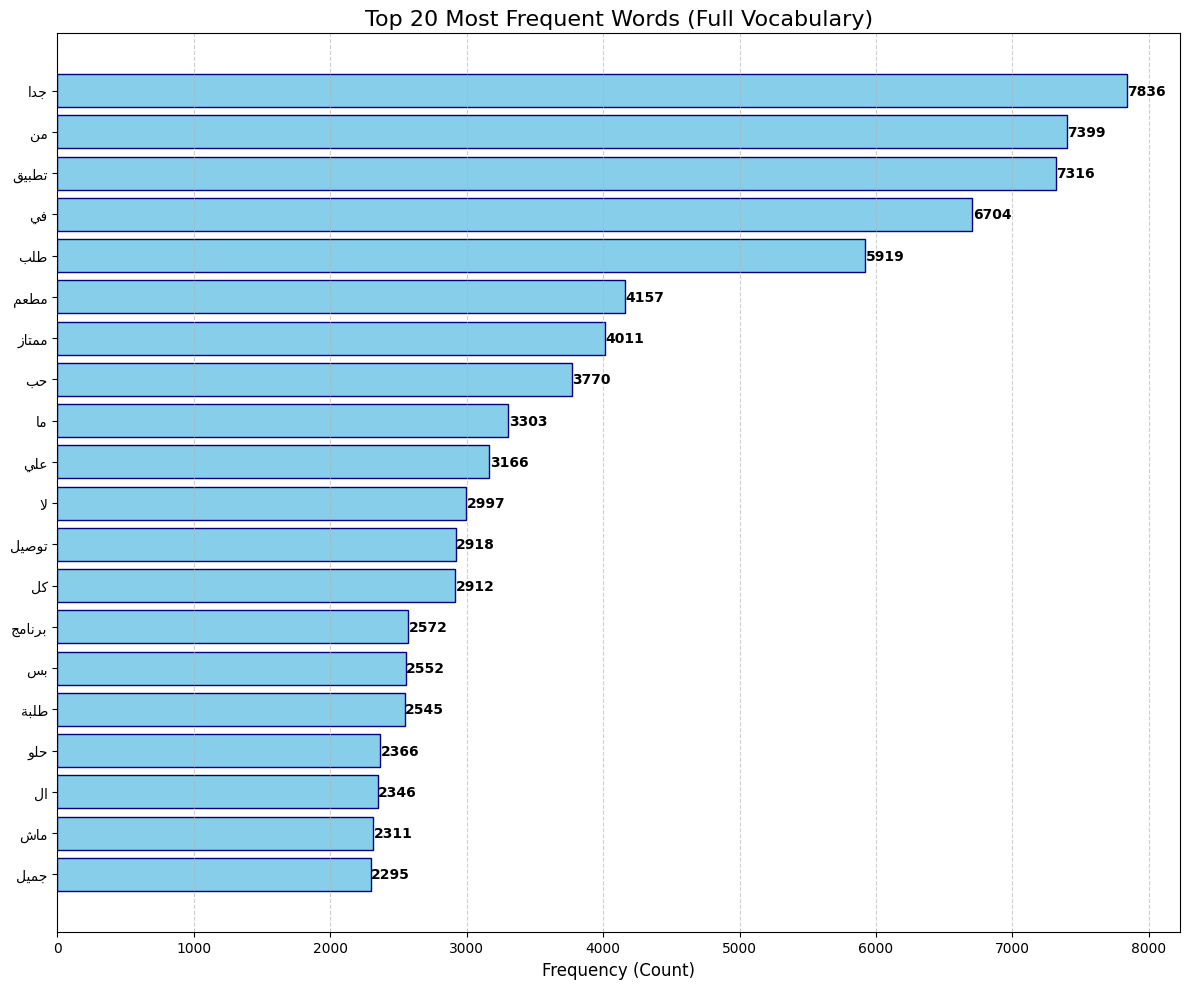

In [ ]:
# --- STEP 5: Top 20 Word Frequency Visualization
# Note: No manual filtering is applied here as per the Preprocessing team's workflow.

# 1. Flatten the list of lemmatized tokens into a single list
all_words = [word for sublist in df['lemmatized_tokens'] for word in sublist]

# 2. Count the occurrences of each word (including stop words)
word_counts = Counter(all_words)

# 3. Extract the top 20 most frequent words
common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

# 4. CRITICAL: Fix Arabic text display (Reshape & Bidi)
# This ensures words appear correctly in the chart
fixed_words = [get_display(reshape(w)) for w in words]

# 5. Create the Horizontal Bar Chart
plt.figure(figsize=(12, 10))
bars = plt.barh(fixed_words, counts, color='skyblue', edgecolor='navy')

# 6. Add labels and English documentation
plt.xlabel('Frequency (Count)', fontsize=12)
plt.title('Top 20 Most Frequent Words (Full Vocabulary)', fontsize=16)
plt.gca().invert_yaxis()  # Keep the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 7. Annotate each bar with its exact frequency value
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

I kept the stop words because Word2Vec learns from the context. Removing words like **(لا) or (جداً)** would change the review from negative to positive, or lose its strength.

-------------------------------------------------------------

##**Summary results:**

##Why did we use it for our reviews?
##1. Context & Meaning: It knows that words like **"ممتاز"** and **"رائع"**  have the same vibe. So, the model treats them similarly because they appear in the same type of reviews.

##2. Keeping it Simple: We turned 40,000+ different words into a clean matrix of just 100 features (X_w2v). This makes it much easier and faster for our next model to learn without getting overwhelmed.
##3. Why we kept Stop Words: This is the most important part! We didn't delete words like "لا" (No) or "جداً" (Very) because in Arabic reviews, they change everything. "جيد" (Good) is totally different from "ليس جيد" (Not good). Word2Vec helps the machine understand these small but huge differences.


-----------------------------------------------------------------


 **References Phase2:**
- https://github.com/h9-tect/Arabic_nlp_preprocessing
- https://medium.com/@ebimsv/nlp-series-day-5-handling-emojis-strategies-and-code-implementation-0f8e77e3a25c
- https://youtu.be/NVIL66zEPNc?si=f7VmaN0u9PrABb-J

- https://youtu.be/tKyUPZ_PPTA?si=QQoj33Ps54NeAst4

- https://youtu.be/hhjn4HVEdy0?si=jBpFQtYnDtoU7ojt

- https://realpython.com/regex-python/

- https://www.mdpi.com/2078-2489/15/6/316
------------------------------

**References phase3**:


TF-IDF


* https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

* https://www.kaggle.com/code/faressayah/natural-language-processing-nlp-for-beginners

* https://youtu.be/iBZCyaSErfM?si=bNhMCVqxsgRqPG-N

Word2Vec

*   https://youtu.be/ZjaMvO3VEdU?si=s471uab0AIRpPnDX
*  https://radimrehurek.com/gensim/models/word2vec.html

